In [ ]:
!pip install mp-api pymatgen torch-geometric

In [ ]:
!pip install mp-api pymatgen pandas


# Setting Librarry

In [3]:
from mp_api.client import MPRester
import pandas as pd

# Mengambil Material

In [4]:
# Materials Project API
API_KEY = "czPKGKOpzKKAvEin6xXMyLnBRSVKzsbE"


In [5]:
with MPRester(API_KEY) as mpr:

    # ======================
    # Metal (1000)
    # ======================
    metal = list(
        mpr.materials.summary.search(
            band_gap=(0, 0),
            fields=[
                "material_id",
                "formula_pretty",
                "band_gap",
                "structure",
                "formation_energy_per_atom",
                "is_metal"
            ],
            chunk_size=1000,
            num_chunks=1
        )
    )

    # ======================
    # Semimetal (1000)
    # ======================
    semimetal = list(
        mpr.materials.summary.search(
            band_gap=(0.001, 0.5),
            fields=[
                "material_id",
                "formula_pretty",
                "band_gap",
                "structure",
                "formation_energy_per_atom",
                "is_metal"
            ],
            chunk_size=1000,
            num_chunks=1
        )
    )

    # ======================
    # Semiconductor (1000)
    # ======================
    semiconductor = list(
        mpr.materials.summary.search(
            band_gap=(0.5, 3),
            fields=[
                "material_id",
                "formula_pretty",
                "band_gap",
                "structure",
                "formation_energy_per_atom",
                "is_metal"
            ],
            chunk_size=1000,
            num_chunks=1
        )
    )

# ======================
# Gabungkan
# ======================
docs = metal + semimetal + semiconductor

print(f"Total material: {len(docs)}")

# ======================
# Ubah ke DataFrame
# ======================
rows = []

for doc in docs:

    if doc.is_metal:
        category = "Metal"
    elif doc.band_gap <= 0.5:
        category = "Semimetal"
    else:
        category = "Semiconductor"

    rows.append({
        "material_id": str(doc.material_id),
        "formula": doc.formula_pretty,
        "band_gap": doc.band_gap,
        "formation_energy": doc.formation_energy_per_atom,
        "category": category,
        "structure": doc.structure
    })
df = pd.DataFrame(rows)


Retrieving SummaryDoc documents:   0%|          | 0/1000 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1000 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1000 [00:00<?, ?it/s]

Total material: 3000


In [6]:
df.head()

,material_id,formula,band_gap,formation_energy,category,structure
0,mp-10018,Ac,0.0,0.021639,Metal,[[0. 0. 0.] Ac]
1,mp-862690,Ac,0.0,0.000000,Metal,"[[0. 0. 0.] Ac, [-3.50000700e-07 2.33598723e+..."
2,mp-1183057,Ac,0.0,0.015586,Metal,"[[2.6219238 0. 0. ] Ac, [ 0.69036..."
3,mp-1183069,Ac,0.0,0.011822,Metal,"[[0. 0. 0.] Ac, [ 1.11022302e-16 -2.33645283e+..."
4,mp-861724,Ac2AgIr,0.0,-0.413285,Metal,"[[3.80476513 3.80476513 3.80476513] Ac, [0. 0...."


In [12]:
df['category'].value_counts


<bound method IndexOpsMixin.value_counts of 0               Metal
1               Metal
2               Metal
3               Metal
4               Metal
            ...      
2995    Semiconductor
2996    Semiconductor
2997    Semiconductor
2998    Semiconductor
2999    Semiconductor
Name: category, Length: 3000, dtype: object>

In [8]:
# Melihat material metal
metal = df[df["category"] == "Metal"]

print(metal[["material_id", "formula", "band_gap"]].head(10))

  material_id  formula  band_gap
0    mp-10018       Ac       0.0
1   mp-862690       Ac       0.0
2  mp-1183057       Ac       0.0
3  mp-1183069       Ac       0.0
4   mp-861724  Ac2AgIr       0.0
5  mp-1183076  Ac2AgPb       0.0
6  mp-1207297  Ac2Br2O       0.0
7  mp-1183068  Ac2CdGa       0.0
8  mp-1183063  Ac2CdGe       0.0
9  mp-1183086  Ac2CdHg       0.0


In [13]:
# Melihat material semimetal
metal = df[df["category"] == "Semimetal"]

metal[["material_id", "formula", "band_gap"]].head(10)

,material_id,formula,band_gap
1000,mp-867311,AcAgTe2,0.0748
1001,mp-861884,AcGaTe2,0.4914
1002,mp-861460,AcInTe2,0.3799
1003,mp-1184231,AcMg149,0.2168
1004,mp-866056,AcN,0.0615
1005,mp-18125,Ag(AuF4)2,0.2585
1006,mp-1105028,Ag(MoSe)3,0.2695
1007,mp-732005,Ag(NO2)3,0.1241
1008,mp-1229222,Ag10Te4BrCl,0.2208
1009,mp-1215080,Ag12SBr,0.3945


In [14]:
# Melihat material Semiconductor
metal = df[df["category"] == "Semiconductor"]
metal[["material_id", "formula", "band_gap"]].head(10)

,material_id,formula,band_gap
2000,mp-32800,Ac2S3,2.2729
2001,mp-1183052,AcBO3,0.8071
2002,mp-866101,AcCrO3,2.0031
2003,mp-861502,AcFeO3,1.0084
2004,mp-1183053,AcGaO3,2.8959
2005,mp-861605,AcH3,0.6407
2006,mp-861867,AcI3,2.5886
2007,mp-865028,AcTlTe2,0.6217
2008,mp-567334,Ag(BCl)6,2.6955
2009,mp-600237,Ag(CO)2,0.7095


In [15]:
# Simpan Data
df.to_csv("Data Material.csv", index=False)

# EDA (Exploratory Data Analysis)

In [18]:
print(df.shape)

print(df.info())

print(df.head())

(3000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   material_id       3000 non-null   object 
 1   formula           3000 non-null   object 
 2   band_gap          3000 non-null   float64
 3   formation_energy  3000 non-null   float64
 4   category          3000 non-null   object 
 5   structure         3000 non-null   object 
dtypes: float64(2), object(4)
memory usage: 140.8+ KB
None
  material_id  formula  band_gap  formation_energy category  \
0    mp-10018       Ac       0.0          0.021639    Metal   
1   mp-862690       Ac       0.0          0.000000    Metal   
2  mp-1183057       Ac       0.0          0.015586    Metal   
3  mp-1183069       Ac       0.0          0.011822    Metal   
4   mp-861724  Ac2AgIr       0.0         -0.413285    Metal   

                                           structure  
0              

In [19]:
# Handle Missing Value
df.isnull().sum()

material_id         0
formula             0
band_gap            0
formation_energy    0
category            0
structure           0
dtype: int64

In [20]:
df.describe()

,band_gap,formation_energy
count,3000.000000,3000.000000
mean,0.619298,-0.976021
std,0.840735,1.152450
min,0.000000,-3.938449
25%,0.000000,-1.853772
50%,0.189500,-0.762215
75%,1.060575,-0.227367
max,2.997300,4.159950


In [21]:
print(df["category"].value_counts())

category
Metal            1001
Semiconductor    1000
Semimetal         999
Name: count, dtype: int64


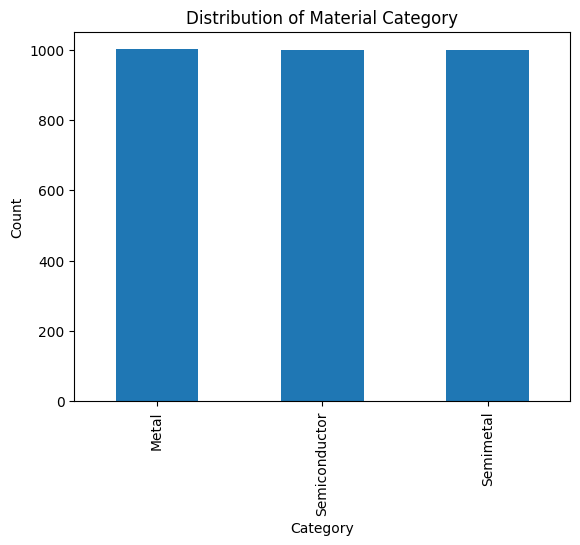

In [22]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Distribution of Material Category")

plt.show()

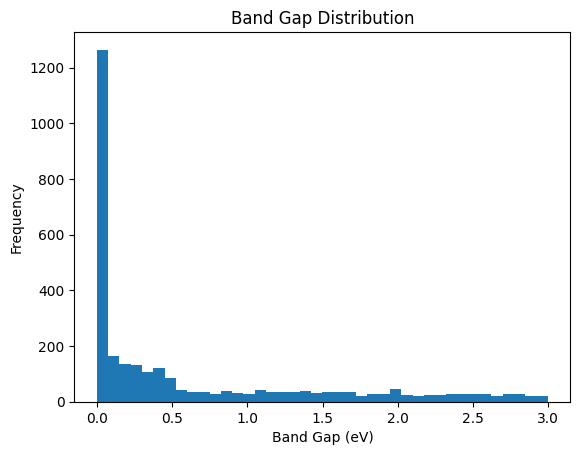

In [23]:
plt.hist(df["band_gap"], bins=40)

plt.xlabel("Band Gap (eV)")
plt.ylabel("Frequency")
plt.title("Band Gap Distribution")

plt.show()

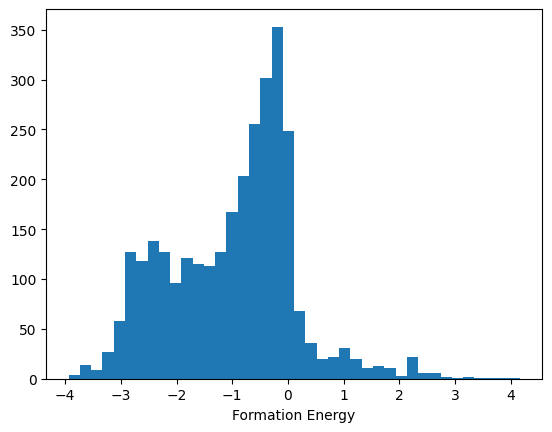

In [24]:
plt.hist(df["formation_energy"], bins=40)

plt.xlabel("Formation Energy")

plt.show()

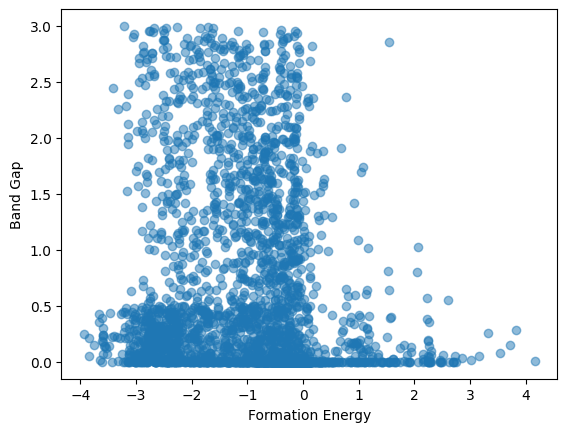

In [25]:
plt.scatter(
    df["formation_energy"],
    df["band_gap"],
    alpha=0.5
)

plt.xlabel("Formation Energy")

plt.ylabel("Band Gap")

plt.show()

<Figure size 700x500 with 0 Axes>

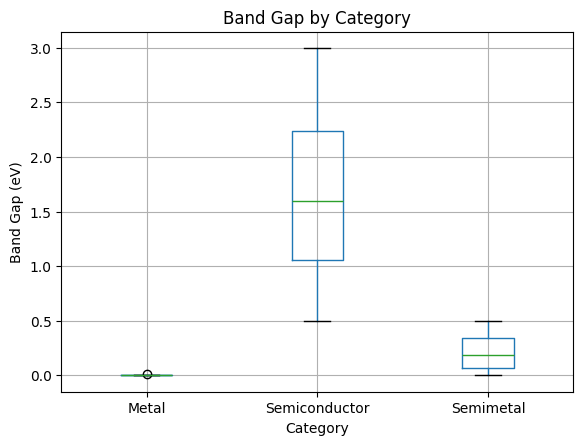

In [30]:
plt.figure(figsize=(7,5))

df.boxplot(column="band_gap", by="category")

plt.title("Band Gap by Category")
plt.suptitle("")

plt.xlabel("Category")
plt.ylabel("Band Gap (eV)")

plt.show()

# Structure → Graph (learn from 1 material)

In [33]:
df.head()

,material_id,formula,band_gap,formation_energy,category,structure
0,mp-10018,Ac,0.0,0.021639,Metal,[[0. 0. 0.] Ac]
1,mp-862690,Ac,0.0,0.000000,Metal,"[[0. 0. 0.] Ac, [-3.50000700e-07 2.33598723e+..."
2,mp-1183057,Ac,0.0,0.015586,Metal,"[[2.6219238 0. 0. ] Ac, [ 0.69036..."
3,mp-1183069,Ac,0.0,0.011822,Metal,"[[0. 0. 0.] Ac, [ 1.11022302e-16 -2.33645283e+..."
4,mp-861724,Ac2AgIr,0.0,-0.413285,Metal,"[[3.80476513 3.80476513 3.80476513] Ac, [0. 0...."


In [43]:
# Melihat Jumlah Atom 
structure = df.loc[0, "structure"]
print("Jumlah Atom:", len(structure))
print(structure)

Jumlah Atom: 1
Full Formula (Ac1)
Reduced Formula: Ac
abc   :   4.027830   4.027829   4.027830
angles:  59.999995  60.000001  59.999995
pbc   :       True       True       True
Sites (1)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Ac     -0   -0    0


In [46]:
# Melihat Atom Penyusun
for site in structure:
    print(site.specie)

#  Melihat Koordinat Atom 

for site in structure:
    print(site.coords)

Ac
[0. 0. 0.]


Dalam graph:

1. Node = atom
2. Feature = sifat atom

Misalnya kita gunakan:

1. Atomic Number
2. Atomic Mass
3. Electronegativity
4. Atomic Radius
5. Group
6. Period

In [48]:
from pymatgen.core.periodic_table import Element

def atom_features(site):

    e = Element(site.specie.symbol)

    return [
        e.Z,
        float(e.atomic_mass),
        e.X if e.X else 0,
        float(e.atomic_radius or 0),
        e.group if e.group else 0,
        e.row
    ]

In [49]:
# melihat isi node features 
for site in structure:
    print(atom_features(site))

[89, 227.0, 1.1, 1.95, 3, 7]


In [52]:
# membuat matrix tensor
import torch 

x = torch.tensor(
    [atom_features(site) for site in structure],
    dtype=torch.float
)

print(x)
print(x.shape)

tensor([[ 89.0000, 227.0000,   1.1000,   1.9500,   3.0000,   7.0000]])
torch.Size([1, 6])


Artinya adalah dalam 1 atom ada 6 fitur per atom

Pada graph GNN:

1. Node = atom
2. Edge = hubungan antar atom (tetangga/ikatan)

Pada graph GNN:

1. Node = atom

2. Edge = hubungan antar atom (tetangga/ikatan)

In [53]:
from pymatgen.analysis.local_env import CrystalNN

cnn = CrystalNN()

In [60]:
structure = df.loc[100, "structure"]

In [61]:
for i in range(len(structure)):

    neighbors = cnn.get_nn_info(structure, i)

    print(f"\nAtom {i} ({structure[i].specie})")

    for n in neighbors:
        print(
            "Neighbor:",
            n["site"].specie,
            "Index:",
            n["site_index"]
        )


Atom 0 (Ac)
Neighbor: Zn Index: 6
Neighbor: Zn Index: 6
Neighbor: Zn Index: 7
Neighbor: Zn Index: 7
Neighbor: Ac Index: 1
Neighbor: Ac Index: 2
Neighbor: Ac Index: 4
Neighbor: Ac Index: 4
Neighbor: Ac Index: 5
Neighbor: Ac Index: 5
Neighbor: Ac Index: 1
Neighbor: Ac Index: 2

Atom 1 (Ac)
Neighbor: Zn Index: 6
Neighbor: Zn Index: 6
Neighbor: Zn Index: 7
Neighbor: Zn Index: 7
Neighbor: Ac Index: 0
Neighbor: Ac Index: 2
Neighbor: Ac Index: 3
Neighbor: Ac Index: 3
Neighbor: Ac Index: 5
Neighbor: Ac Index: 5
Neighbor: Ac Index: 0
Neighbor: Ac Index: 2

Atom 2 (Ac)
Neighbor: Zn Index: 6
Neighbor: Zn Index: 6
Neighbor: Zn Index: 7
Neighbor: Zn Index: 7
Neighbor: Ac Index: 1
Neighbor: Ac Index: 0
Neighbor: Ac Index: 4
Neighbor: Ac Index: 4
Neighbor: Ac Index: 3
Neighbor: Ac Index: 3
Neighbor: Ac Index: 0
Neighbor: Ac Index: 1

Atom 3 (Ac)
Neighbor: Zn Index: 7
Neighbor: Zn Index: 7
Neighbor: Zn Index: 6
Neighbor: Zn Index: 6
Neighbor: Ac Index: 4
Neighbor: Ac Index: 5
Neighbor: Ac Index: 1
Ne

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:4029: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:4031: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:3943: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


In [62]:
edges = []

for i in range(len(structure)):

    neighbors = cnn.get_nn_info(structure, i)

    for n in neighbors:

        j = n["site_index"]

        edges.append([i, j])

In [63]:
print(edges)

[[0, np.int64(6)], [0, np.int64(6)], [0, np.int64(7)], [0, np.int64(7)], [0, np.int64(1)], [0, np.int64(2)], [0, np.int64(4)], [0, np.int64(4)], [0, np.int64(5)], [0, np.int64(5)], [0, np.int64(1)], [0, np.int64(2)], [1, np.int64(6)], [1, np.int64(6)], [1, np.int64(7)], [1, np.int64(7)], [1, np.int64(0)], [1, np.int64(2)], [1, np.int64(3)], [1, np.int64(3)], [1, np.int64(5)], [1, np.int64(5)], [1, np.int64(0)], [1, np.int64(2)], [2, np.int64(6)], [2, np.int64(6)], [2, np.int64(7)], [2, np.int64(7)], [2, np.int64(1)], [2, np.int64(0)], [2, np.int64(4)], [2, np.int64(4)], [2, np.int64(3)], [2, np.int64(3)], [2, np.int64(0)], [2, np.int64(1)], [3, np.int64(7)], [3, np.int64(7)], [3, np.int64(6)], [3, np.int64(6)], [3, np.int64(4)], [3, np.int64(5)], [3, np.int64(1)], [3, np.int64(1)], [3, np.int64(2)], [3, np.int64(2)], [3, np.int64(4)], [3, np.int64(5)], [4, np.int64(7)], [4, np.int64(7)], [4, np.int64(6)], [4, np.int64(6)], [4, np.int64(3)], [4, np.int64(5)], [4, np.int64(0)], [4, np.in

In [65]:
import torch

edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()
print(edge_index)

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [6, 6, 7, 7, 1, 2, 4, 4, 5, 5, 1, 2, 6, 6, 7, 7, 0, 2, 3, 3, 5, 5, 0, 2,
         6, 6, 7, 7, 1, 0, 4, 4, 3, 3, 0, 1, 7, 7, 6, 6, 4, 5, 1, 1, 2, 2, 4, 5,
         7, 7, 6, 6, 3, 5, 0, 0, 2, 2, 3, 5, 7, 7, 6, 6, 3, 4, 0, 0, 1, 1, 4, 3,
         2, 2, 1, 1, 0, 0, 5, 5, 4, 3, 4, 3, 5, 5, 3, 3, 4, 4, 2, 2, 0, 1, 0, 1]])


In [67]:
print(edge_index.shape)

torch.Size([2, 96])


In [ ]:
for i in range(96):
    print(
        edge_index[0, i].item(),
        "->",
        edge_index[1, i].item()
    )

Apa itu edge_attr?

Misalnya ada graph:

C -------- O

Tanpa edge_attr, model hanya tahu:

Atom C terhubung dengan atom O.

Dengan edge_attr, model juga tahu:

Atom C terhubung dengan atom O dengan jarak 1.23 Å.

Informasi ini sangat berpengaruh terhadap sifat material seperti band gap

In [76]:
# Menghitng Jarak antar atom 
structure = df.loc[100, "structure"] # Mengecek material ke 99
print(structure.get_distance(0,1))

3.6177519153019992


In [77]:
edges = []
edge_attr = []

for i in range(len(structure)):

    neighbors = cnn.get_nn_info(structure, i)

    for n in neighbors:

        j = n["site_index"]

        edges.append([i, j])

        distance = structure.get_distance(i, j)

        edge_attr.append([distance])

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:4029: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:4031: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:3943: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


In [79]:
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

edge_attr = torch.tensor(edge_attr, dtype=torch.float)

print(edge_index.shape)
print(edge_attr.shape)

torch.Size([2, 96])
torch.Size([96, 1])


C:\Users\USER\AppData\Local\Temp\ipykernel_652\3873377072.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_attr = torch.tensor(edge_attr, dtype=torch.float)


Artinya:

1. Ada 96 edge.
2. Setiap edge memiliki 1 fitur (jarak).

# Membuat Dataset Graph

In [82]:
# Membuat Library

import torch
from torch_geometric.data import Data
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.core.periodic_table import Element

cnn = CrystalNN()

In [101]:
# Membuat Fungsi Fitur Atom 
def atom_features(site):

    e = Element(site.specie.symbol)

    return [
        e.Z,                              # Atomic Number
        float(e.atomic_mass),             # Atomic Mass
        e.X if e.X else 0.0,              # Electronegativity
        float(e.atomic_radius or 0.0),    # Atomic Radius
        e.group if e.group else 0,        # Group
        e.row                             # Period
    ]

In [102]:
print(atom_features(structure[0]))

[89, 227.0, 1.1, 1.95, 3, 7]


In [85]:
# Membuat fungsi Structure to Graph

def structure_to_graph(structure, band_gap):

    # ======================
    # Node Features
    # ======================
    x = torch.tensor(
        [atom_features(site) for site in structure],
        dtype=torch.float
    )

    # ======================
    # Edge
    # ======================
    edges = []
    edge_attr = []

    for i in range(len(structure)):

        neighbors = cnn.get_nn_info(structure, i)

        for n in neighbors:

            j = n["site_index"]

            # Hindari duplikasi edge
            if i < j:

                edges.append([i, j])
                edges.append([j, i])  # graph tak berarah

                distance = structure.get_distance(i, j)

                edge_attr.append([distance])
                edge_attr.append([distance])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # ======================
    # Target
    # ======================
    y = torch.tensor([band_gap], dtype=torch.float)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

In [87]:
# uji salah satu Material 

graph = structure_to_graph(
    df.loc[100, 'structure'],
    df.loc[100, 'band_gap']
)

print(graph)

Data(x=[8, 6], edge_index=[2, 96], edge_attr=[96, 1], y=[1])


In [89]:
graphs = []

for idx, row in df.iterrows():

    try:
        graph = structure_to_graph(
            row["structure"],
            row["band_gap"]
        )

        graphs.append(graph)

    except Exception as e:
        print(f"Gagal pada index {idx}: {e}")

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:4029: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:4031: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:3943: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


Gagal pada index 1242: No Voronoi neighbors found for site - try increasing cutoff
Gagal pada index 1256: No Voronoi neighbors found for site - try increasing cutoff
Gagal pada index 1360: No Voronoi neighbors found for site - try increasing cutoff
Gagal pada index 2449: No Voronoi neighbors found for site - try increasing cutoff


In [90]:
print(f"Jumlah Graph: {len(graphs)}")

Jumlah Graph: 2996


In [91]:
import pickle 
with open("graph_dataset.pkl", "wb") as f:
    pickle.dump(graphs, f)
print("dataset graph berhasil disimpan.")

dataset graph berhasil disimpan.


# ML Focus


In [93]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

In [94]:
train_graphs, temp_graphs = train_test_split(
    graphs,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_graphs, test_graphs = train_test_split(
    temp_graphs,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

In [184]:
print("Train :", len(train_graphs))
print("Validation :", len(val_graphs))
print("Test :", len(test_graphs))

Train : 2097
Validation : 449
Test : 450


In [96]:
train_loader = DataLoader(
    train_graphs,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_graphs,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs,
    batch_size=32,
    shuffle=False
) 

In [97]:
batch = next(iter(train_loader))

print(batch)

DataBatch(x=[917, 6], edge_index=[2, 3158], edge_attr=[3158, 1], y=[32], batch=[917], ptr=[33])


In [164]:
import torch
import torch.nn.functional as F

from torch.nn import Linear, BatchNorm1d, Dropout
from torch_geometric.nn import CGConv, global_mean_pool


In [165]:
class BandGapCGNN(torch.nn.Module):

    def __init__(self,
                 in_channels=6,
                 hidden_channels=64,
                 edge_dim=1):

        super().__init__()

        # Embedding Layer
        self.embedding = Linear(in_channels, hidden_channels)

        # Graph Convolution Layers
        self.conv1 = CGConv(hidden_channels, dim=edge_dim)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = CGConv(hidden_channels, dim=edge_dim)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = CGConv(hidden_channels, dim=edge_dim)
        self.bn3 = BatchNorm1d(hidden_channels)

        # Fully Connected Layers
        self.fc1 = Linear(hidden_channels, 32)
        self.dropout = Dropout(0.2)
        self.fc2 = Linear(32, 1)

    def forward(self, x, edge_index, edge_attr, batch):

        # Embedding
        x = self.embedding(x)

        # ----- Block 1 -----
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)

        # ----- Block 2 -----
        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        # ----- Block 3 -----
        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)

        # Pooling
        x = global_mean_pool(x, batch)

        # Regression Head
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [167]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BandGapCGNN().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

In [168]:
criterion = torch.nn.SmoothL1Loss()

In [169]:
def train():

    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch
        )

        loss = criterion(
            pred.squeeze(),
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [170]:
def validate():

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for batch in val_loader:

            batch = batch.to(device)

            pred = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr,
                batch.batch
            )

            loss = criterion(
                pred.squeeze(),
                batch.y
            )

            total_loss += loss.item()

    return total_loss / len(val_loader)

In [171]:
best_val_loss = float("inf")

train_losses = []
val_losses = []

EPOCHS = 100

for epoch in range(EPOCHS):

    train_loss = train()

    val_loss = validate()

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f}"
    )

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:1074: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


Epoch 001 | Train: 0.2896 | Val: 0.3394
Epoch 002 | Train: 0.2542 | Val: 0.2705
Epoch 003 | Train: 0.2353 | Val: 0.2579
Epoch 004 | Train: 0.2240 | Val: 0.2464
Epoch 005 | Train: 0.2235 | Val: 0.2532
Epoch 006 | Train: 0.2148 | Val: 0.2549
Epoch 007 | Train: 0.2112 | Val: 0.2276
Epoch 008 | Train: 0.2129 | Val: 0.2229
Epoch 009 | Train: 0.2095 | Val: 0.2272
Epoch 010 | Train: 0.2028 | Val: 0.2300
Epoch 011 | Train: 0.2067 | Val: 0.2060
Epoch 012 | Train: 0.2059 | Val: 0.2378
Epoch 013 | Train: 0.2030 | Val: 0.2143
Epoch 014 | Train: 0.1928 | Val: 0.2039
Epoch 015 | Train: 0.2000 | Val: 0.2061
Epoch 016 | Train: 0.1876 | Val: 0.2051
Epoch 017 | Train: 0.2090 | Val: 0.2350
Epoch 018 | Train: 0.1995 | Val: 0.2123
Epoch 019 | Train: 0.1943 | Val: 0.2044
Epoch 020 | Train: 0.1892 | Val: 0.2028
Epoch 021 | Train: 0.1934 | Val: 0.2006
Epoch 022 | Train: 0.1851 | Val: 0.2073
Epoch 023 | Train: 0.1911 | Val: 0.1968
Epoch 024 | Train: 0.1829 | Val: 0.2062
Epoch 025 | Train: 0.1814 | Val: 0.2051


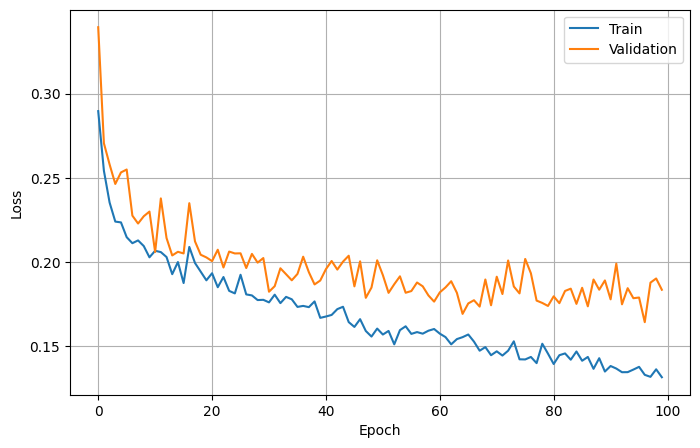

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train")

plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [178]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

BandGapCGNN(
  (embedding): Linear(in_features=6, out_features=64, bias=True)
  (conv1): CGConv(64, dim=1)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): CGConv(64, dim=1)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): CGConv(64, dim=1)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

In [179]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

predictions = []
targets = []

model.eval()

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch
        )

        predictions.extend(
            pred.squeeze().cpu().numpy()
        )

        targets.extend(
            batch.y.cpu().numpy()
        )

In [180]:
mae = mean_absolute_error(targets, predictions)

rmse = np.sqrt(
    mean_squared_error(targets, predictions)
)

r2 = r2_score(targets, predictions)

print("="*30)
print("Evaluation Result")
print("="*30)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Evaluation Result
MAE  : 0.3859
RMSE : 0.5893
R²   : 0.5356


In [183]:
for i in range(100):

    print(
        f"Actual : {targets[i]:.3f} eV"
        f" | Predicted : {predictions[i]:.3f} eV"
    )

Actual : 0.000 eV | Predicted : 0.016 eV
Actual : 0.196 eV | Predicted : 0.228 eV
Actual : 0.000 eV | Predicted : 0.069 eV
Actual : 0.000 eV | Predicted : 0.068 eV
Actual : 0.266 eV | Predicted : 1.168 eV
Actual : 0.310 eV | Predicted : 0.383 eV
Actual : 0.000 eV | Predicted : 0.069 eV
Actual : 0.746 eV | Predicted : 1.247 eV
Actual : 0.000 eV | Predicted : 0.159 eV
Actual : 0.280 eV | Predicted : 0.295 eV
Actual : 2.936 eV | Predicted : 2.925 eV
Actual : 1.316 eV | Predicted : 1.135 eV
Actual : 0.000 eV | Predicted : 1.962 eV
Actual : 2.493 eV | Predicted : 1.167 eV
Actual : 1.300 eV | Predicted : 1.064 eV
Actual : 0.000 eV | Predicted : 0.029 eV
Actual : 2.090 eV | Predicted : 1.657 eV
Actual : 2.434 eV | Predicted : 1.739 eV
Actual : 0.000 eV | Predicted : 0.093 eV
Actual : 1.153 eV | Predicted : 0.637 eV
Actual : 0.146 eV | Predicted : 0.212 eV
Actual : 1.100 eV | Predicted : 0.514 eV
Actual : 0.405 eV | Predicted : 0.221 eV
Actual : 2.560 eV | Predicted : 2.381 eV
Actual : 0.000 e

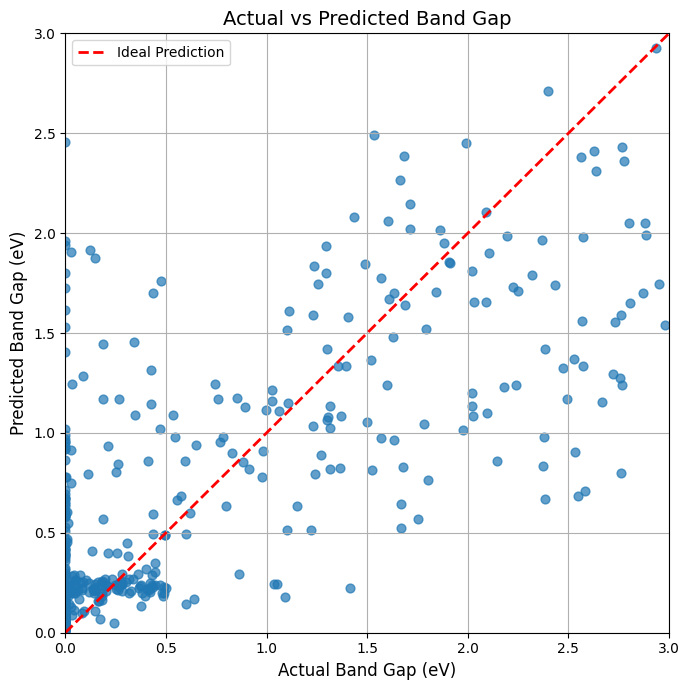

In [182]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    targets,
    predictions,
    s=40,
    alpha=0.7
)

# Garis ideal
plt.plot(
    [0, 3],
    [0, 3],
    'r--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.xlim(0, 3)
plt.ylim(0, 3)

plt.xlabel("Actual Band Gap (eV)", fontsize=12)
plt.ylabel("Predicted Band Gap (eV)", fontsize=12)
plt.title("Actual vs Predicted Band Gap", fontsize=14)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()